# MPW2 - Computational graphs


- Student: Rino Albertin
- Student: Dany Ferreira


In [1]:
import os
import sys
from importlib.util import find_spec
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.linalg import inv


def _is_running_on_colab() -> bool:
    """Return True when executed inside Google Colab."""
    return find_spec("google.colab") is not None


ON_COLAB = _is_running_on_colab()

if ON_COLAB:
    if not os.path.exists("/content/MSE_FTP_DeLearn"):
        os.system("git clone https://github.com/Rinovative/MSE_FTP_DeLearn.git")

    os.chdir("/content/MSE_FTP_DeLearn")

    repo_src = "/content/MSE_FTP_DeLearn/src"
    if repo_src not in sys.path:
        sys.path.insert(0, repo_src)

    REPO_ROOT = Path("/content/MSE_FTP_DeLearn")
else:
    REPO_ROOT = Path.cwd().parent

    repo_src = str(REPO_ROOT / "src")
    if repo_src not in sys.path:
        sys.path.insert(0, repo_src)

In [2]:
from p02_computational_graphs.cgnodes import *  # noqa: F403

**Reproducibility**

Some experiments use random sampling or random permutations of the training data. To make the results reproducible, a fixed seed is used and a new NumPy random generator is created before each stochastic training run.


In [3]:
SEED = 42


def reset_seed(seed: int = SEED) -> np.random.Generator:
    """Create and return a reproducible NumPy random generator."""
    return np.random.default_rng(seed)

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/02_computational_graphs/simple-graph-1.jpg)


In [4]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset

### 2.1 Read data

We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.


In [5]:
datafile = REPO_ROOT / "data" / "lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [6]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data

Plot a scatter plot of renting price as a function of living area


In [7]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend,
# also optional.
def plot_data_prediction(x_points, y_points, x_curve=None, y_curve=None, x_title="x", y_title="y", theta_0=None, theta_1=None, theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)  # ex "Living area (m^2)"
    plt.ylabel(y_title)  # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = rf"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += rf", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

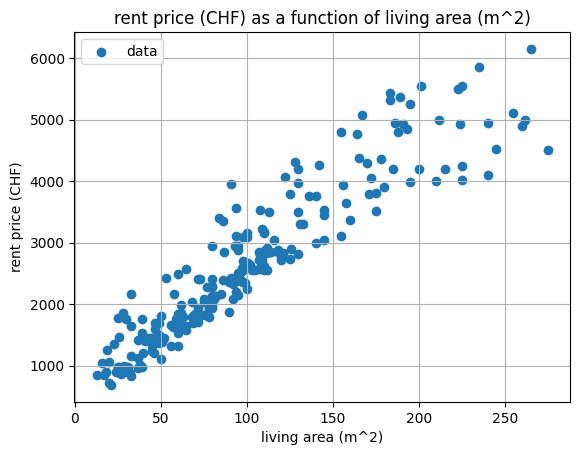

In [8]:
plot_data_prediction(living_area, rent_price, x_title="living area (m^2)", y_title="rent price (CHF)")

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
\hat{y} = h*{\theta}(\mathbf{x}) = \theta*{0} + \theta\_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
J(\theta) = \frac{1}{2N} \sum*{n=1}^{N} (\hat{y}_{n} - y\_{n})^{2}
\end{equation_}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}


intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


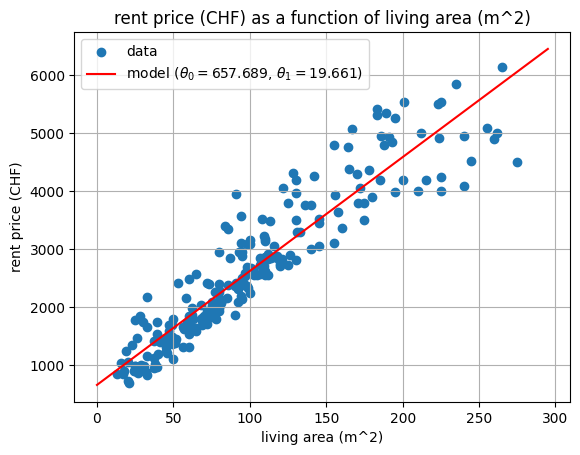

In [9]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y  # TO COMPLETE

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title="living area (m^2)",
    y_title="rent price (CHF)",
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :


In [10]:
def mse_loss(y_hat, y):
    J = 1 / (2 * len(y)) * np.sum((y_hat - y) ** 2)
    return J


y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.


In [11]:
def rmse_loss(y_hat, y):
    J = 1 / len(y) * np.sum((y_hat - y) ** 2)
    return np.sqrt(J)


def mae_loss(y_hat, y):
    J = 1 / len(y) * np.sum(np.abs(y_hat - y))
    return J


def mape_loss(y_hat, y):
    J = 1 / len(y) * np.sum(np.abs((y_hat - y) / y))
    return J


rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?


The RMSE is computed from the mean squared error without the factor $1/2$, while the optimization loss $J$ above includes this factor for simpler gradient derivation. The RMSE is expressed in the same unit as the target variable (CHF), meaning that the model has a root mean squared prediction error of 458 CHF. Comparing RMSE (458 CHF) with MAE (347 CHF), the RMSE is about 32% higher, which indicates that there are a few larger errors that have a stronger impact due to the squaring. The MAPE of 14.6% indicates that the model predicts the rent price with an average relative error of 14.6%. However, MAPE is problematic when the true value $y$ is zero or close to zero, as it causes a division by zero or extremely large values, making the metric unreliable in such cases.


## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/02_computational_graphs/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code **cgnodes.py** with a new operator node **MSELossNode(MetaNode)** that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.


In [12]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()
q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x, theta_1, q)
add = AddNode([q, theta_0], y_hat)
mse = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [13]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [14]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent


In [15]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle("Training log")
    ax1.plot(t0_evolution)
    ax1.set_title("theta 0")
    ax2.plot(t1_evolution)
    ax2.set_title("theta 1")
    ax3.plot(loss_evolution)
    ax3.set_title("loss")
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color="red")
    ax4.set_title("points and model output")
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions.


intercept (theta_0): 1.0194119888656359
slope (theta_1)    : 24.462434732461574
The total value of the loss is 163449.69076912917


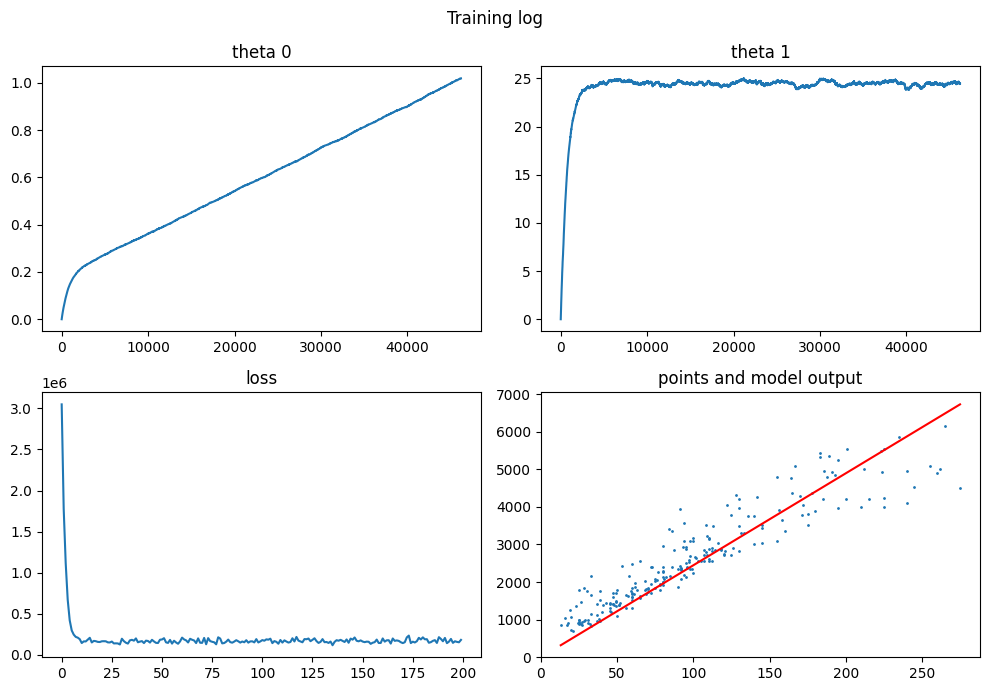

In [16]:
rng = reset_seed()  # to have reproducible results

alpha = 0.0000001  # learning rate
epochs = 200  # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0  # initial value of theta_0
t1 = 0.0  # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []  # to log the evolution of theta_0
t1_evolution = []  # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = rng.integers(0, N)  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 -= alpha * theta_0.grad_v  # update rule for theta_0
        t1 -= alpha * theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of the loss: The loss decreases steeply in the first few epochs from about 3.4e6 to around 1.5e5, after which it stagnates. This indicates that the model stops improving significantly after the initial rapid convergence.
- Evolution of $\theta_1$: $\theta_1$ increases very rapidly in the first few epochs to a value of around 25, close to the optimal value of ~19.7, and then stabilizes with only small fluctuations due to the stochastic nature of SGD.
- Evolution of $\theta_0$: $\theta_0$ shows a very slow and steady increase, reaching only ~1.0 after 200 epochs, far from the optimal value of ~658. This is because the gradients for $\theta_0$ are much smaller than for $\theta_1$, since $\theta_0$ is the bias term and is not multiplied by any feature value. This slow convergence of $\theta_0$ motivates the use of different learning rates for $\theta_0$ and $\theta_1$.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.


intercept (theta_0): 0.4316656133998021
slope (theta_1)    : 24.54610191705361
The total value of the loss is 163536.92571570489


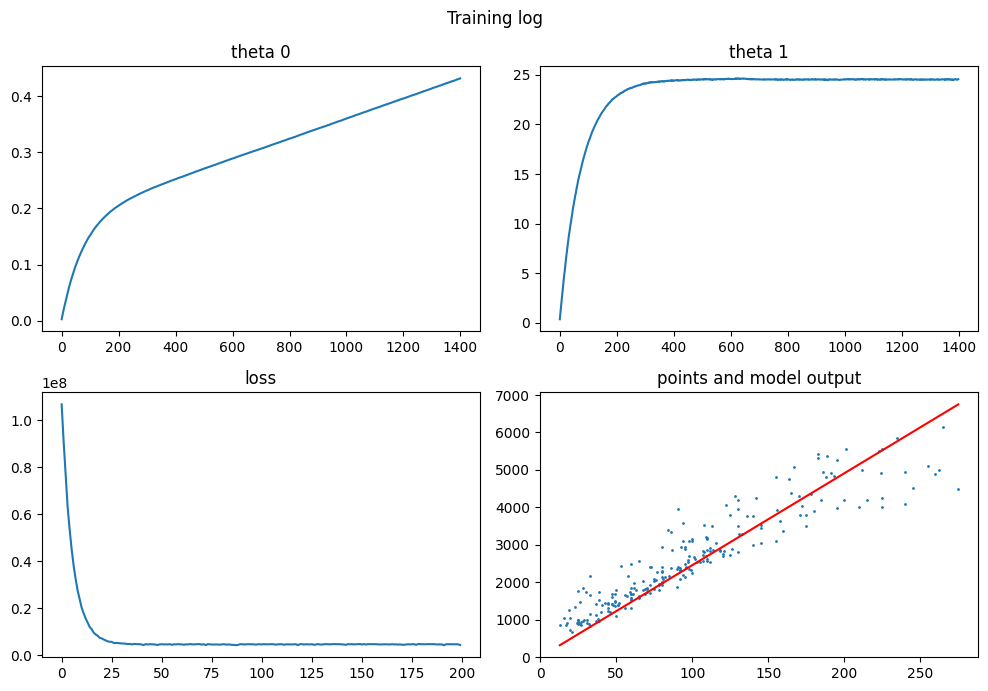

In [17]:
rng = reset_seed()  # to have reproducible results

alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
# as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0
        for i in range(batch_size):
            n = indices[batch * batch_size + i]
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v
        t0 -= alpha * t0_grad_sum / batch_size
        t1 -= alpha * t1_grad_sum / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        # compute the gradients and update theta_0 and theta_1 with the average
        # of the gradients over the batch

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of $\theta_0$ and $\theta_1$: $\theta_1$ shows again a rapid increase in the first few epochs to ~25, but with smaller fluctuations compared to SGD. This is because the gradient is averaged over 32 samples per batch, which reduces the noise in the updates. $\theta_0$ shows the same slow convergence, reaching only ~0.43 after 1400 updates, still far from the optimal value of ~658.
- Do we still have the same observation as in the plain stochastic version regarding the convergence of $\theta_1$ and the slow evolution of $\theta_0$? Yes, $\theta_1$ still converges quickly while $\theta_0$ converges very slowly. The slow convergence of $\theta_0$ is even more visible here as the curve is smoother.
- Can we use larger learning rates than in the plain stochastic version ? Yes, because averaging the gradients over a batch reduces the variance of the updates, making the training more stable and allowing for larger learning rates without diverging.


## 5. Optimizers

### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a smaller learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.


intercept (theta_0): 460.3167941621182
slope (theta_1)    : 21.065008443125887
The total value of the loss is 110222.22940964813


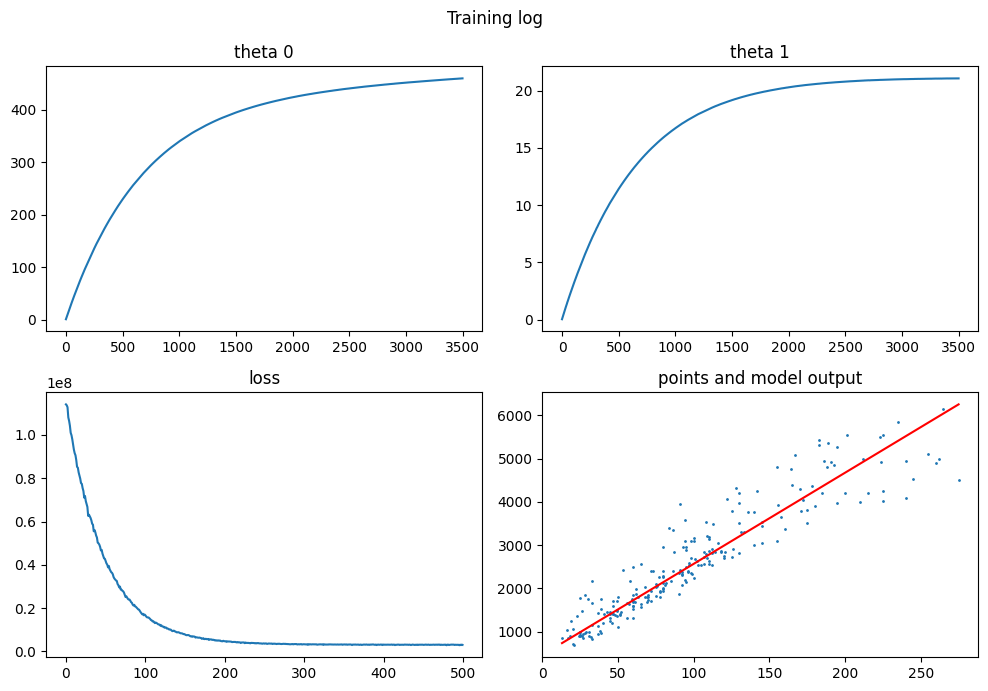

In [18]:
rng = reset_seed()  # to have reproducible results

alpha_t0 = 0.00025  # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500  # number of epochs (an epoch is a loop over the whole training set)

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0
        for i in range(batch_size):
            n = indices[batch * batch_size + i]
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v
        t0 -= alpha_t0 * t0_grad_sum / batch_size
        t1 -= alpha_t1 * t1_grad_sum / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        # compute the gradients and update theta_0 and theta_1 with the average
        # of the gradients over the batch

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**Your observations**

- Evolution of $\theta_1$: The smaller learning rate for $\theta_1$ results in a slower but smoother convergence compared to the previous experiments, reaching ~21 after 3500 batch updates, close to the optimal value of ~19.7.
- Evolution of $\theta_0$: The much larger learning rate for $\theta_0$ shows a significant improvement, reaching ~460 after 3500 batch updates compared to only ~0.43 before. However, it has not yet fully converged to the optimal value of ~658, suggesting that more epochs would be beneficial.
- Evolution of the loss: The loss decreases more smoothly and reaches a lower final value than in the previous experiments, confirming that the use of different learning rates improves the overall convergence.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called _momentum_ that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
\theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.


intercept (theta_0): 669.6929093061527
slope (theta_1)    : 19.650989133985863
The total value of the loss is 104975.81906258686


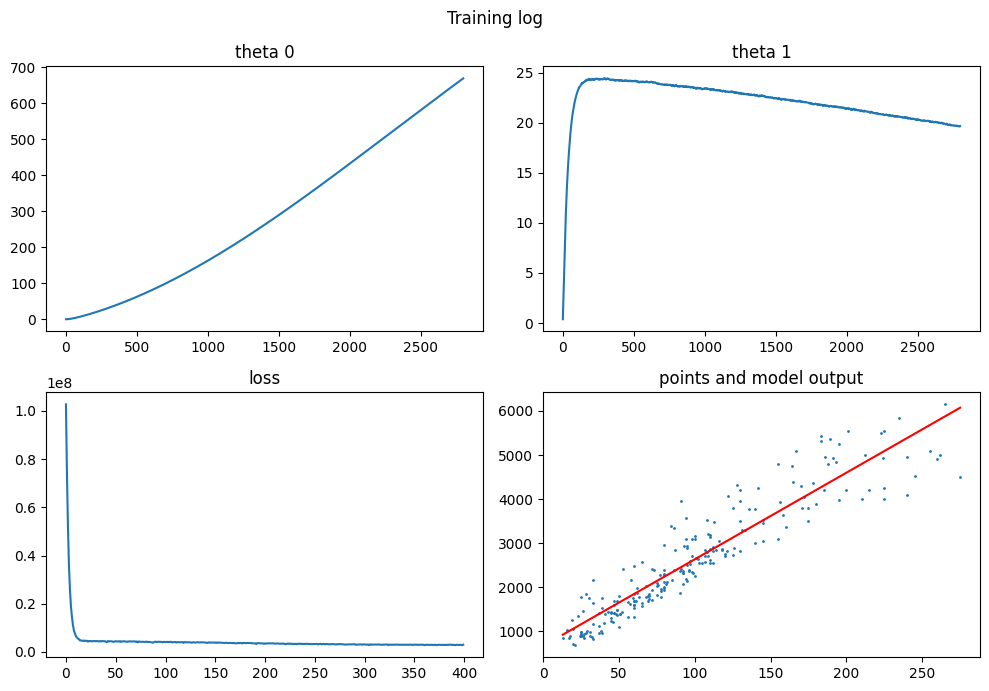

In [19]:
rng = reset_seed()  # to have reproducible results

alpha = 0.000001  # learning rate, ## increased by one order of magnitude compared to plain SGD
beta_momentum_t0 = 0.9999  # momentum factor for theta_0
beta_momentum_t1 = 0.5000  # momentum factor for theta_1
epochs = 400  # number of epochs (an epoch is a loop over the whole training set)

batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0
m0 = 0.0
m1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        for i in range(batch_size):
            n = indices[batch * batch_size + i]
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v
        m0 = beta_momentum_t0 * m0 + alpha * t0_grad_sum / batch_size
        m1 = beta_momentum_t1 * m1 + alpha * t1_grad_sum / batch_size
        t0 -= m0
        t1 -= m1

        t0_evolution.append(t0)
        t1_evolution.append(t1)
        # compute the gradients and update theta_0 and theta_1 with the average
        # of the gradients over the batch

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations**

The learning rate was increased by one order of magnitude from 1e-7 to 1e-6. This is reasonable because momentum accumulates previous update directions and accelerates movement when gradients are consistent. With the chosen momentum factors, excessive overshooting was still controlled and the training remained stable.

- Evolution of $\theta_0$: Momentum strongly accelerates the convergence of $\theta_0$. It reaches 669.69, which is close to the reference value of about 657.69 from the normal equation. The plot also shows that the accumulated momentum does not immediately stop when the optimum is approached. Instead, $\theta_0$ slightly overshoots the reference value before stabilizing.
- Evolution of $\theta_1$: $\theta_1$ converges to 19.65, which is very close to the reference value of about 19.66. The lower momentum factor for $\theta_1$ helps to avoid excessive overshooting.
- Evolution of the loss: The final loss is 104975.82, which is very close to the minimum loss of about 104915.13 obtained with the normal equation. This is clearly better than the previous gradient descent variants.


## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


### 6.1 Zero-mean normalization

In the previous experiments, the living area was used directly as input. Since the living area values are much larger than the constant bias input of $\theta_0$, the gradients of $\theta_0$ and $\theta_1$ have very different magnitudes. This makes optimization harder, because a learning rate that works well for $\theta_1$ may be too small for $\theta_0$.

To improve the optimization behaviour, the input feature is normalized with a zero-mean and unit-standard-deviation transformation:

$$
x_{\text{norm}} = \frac{x - \mu_x}{\sigma_x}
$$

This keeps the target values unchanged, but rescales the input feature. The goal is to compare the convergence behaviour with and without input normalization.


In [20]:
# zero-mean normalization
x_mean = np.mean(living_area)
x_std = np.std(living_area)

living_area_norm = (living_area - x_mean) / x_std

print("Mean of original living area:", x_mean)
print("Std of original living area :", x_std)
print("Mean after normalization    :", np.mean(living_area_norm))
print("Std after normalization     :", np.std(living_area_norm))

# closed-form reference with normalized input
X_norm = np.c_[np.ones(len(living_area_norm)), living_area_norm]
theta_norm = inv(X_norm.T @ X_norm) @ X_norm.T @ rent_price

print("\nReference parameters on normalized input")
print("theta_0_norm:", theta_norm[0])
print("theta_1_norm:", theta_norm[1])

# convert normalized parameters back to the original input scale
theta_1_original = theta_norm[1] / x_std
theta_0_original = theta_norm[0] - theta_norm[1] * x_mean / x_std

print("\nConverted back to original scale")
print("theta_0:", theta_0_original)
print("theta_1:", theta_1_original)

y_hat_norm_ref = theta_norm[0] + theta_norm[1] * living_area_norm
J_norm_ref = mse_loss(y_hat_norm_ref, rent_price)

print("\nReference loss with normalized input:", J_norm_ref)

Mean of original living area: 98.4978354978355
Std of original living area : 60.11387998410601
Mean after normalization    : 0.0
Std after normalization     : 1.0

Reference parameters on normalized input
theta_0_norm: 2594.272727272727
theta_1_norm: 1181.9098117071803

Converted back to original scale
theta_0: 657.6890591150302
theta_1: 19.66117994745431

Reference loss with normalized input: 104915.13056913584


The parameters obtained on the normalized input scale are not directly comparable to the original $\theta$ values, because $\theta_1$ now refers to one standard deviation of living area instead of one square meter. Therefore, the parameters are converted back to the original scale.  
After converting them back, the parameters match the original normal-equation reference up to numerical precision. This shows that normalization does not change the underlying model, but only changes the scale on which the optimization is performed.


Normalized batched gradient descent
theta_0_norm: 2595.0358719631877
theta_1_norm: 1181.6818911614464

Converted back to original scale
intercept theta_0: 658.8256563330303
slope theta_1    : 19.657388467919233

The total value of the loss is 104915.44773793271


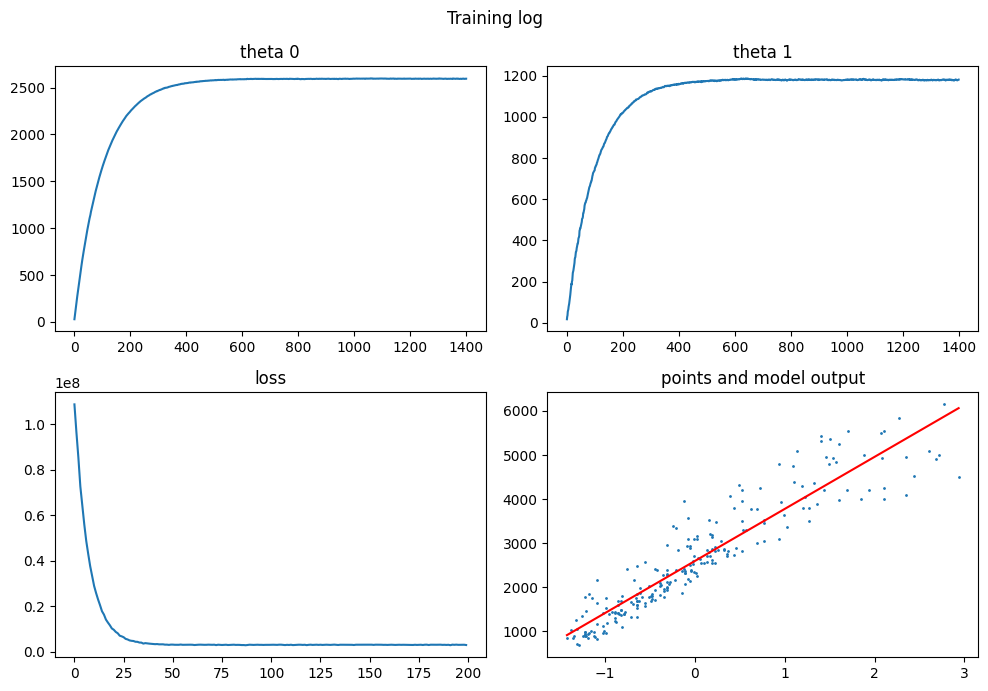

In [21]:
rng = reset_seed()  # to have reproducible results

alpha = 0.01  # much larger learning rate is possible after normalization
epochs = 200
batch_size = 32
N = len(living_area_norm)

t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        for i in range(batch_size):
            n = indices[batch * batch_size + i]

            cg.reset_values()
            cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
            cg.backward()

            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v

        t0 -= alpha * t0_grad_sum / batch_size
        t1 -= alpha * t1_grad_sum / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("Normalized batched gradient descent")
print("theta_0_norm:", t0)
print("theta_1_norm:", t1)

# convert trained normalized parameters back to original scale
t1_batched_norm_original = t1 / x_std
t0_batched_norm_original = t0 - t1 * x_mean / x_std

print("\nConverted back to original scale")
print("intercept theta_0:", t0_batched_norm_original)
print("slope theta_1    :", t1_batched_norm_original)

y_hat_norm = t0 + t1 * living_area_norm
J_batched_norm = mse_loss(y_hat_norm, rent_price)

print("\nThe total value of the loss is", J_batched_norm)

plot_training_log(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    living_area_norm,
    rent_price,
)

_The plot is shown on the normalized input scale, because the model is trained on `living_area_norm`. The final parameters are then converted back to the original input scale so that they can be compared with the normal-equation reference._


**Observations**

- Parameter evolution: After normalization, both parameters converge much more effectively than in the unnormalized batched gradient descent experiment from Section 4.3.
- Final result: After converting the trained parameters back to the original scale, the model reaches $\theta_0$ = 658.83 and $\theta_1$ = 19.66, compared to the normal-equation reference values $\theta_0$ = 657.69 and $\theta_1$ = 19.66. The final loss is 104915.45, which is almost identical to the reference loss of 104915.13.
- Interpretation: Zero-mean normalization does not change the theoretical optimum of the linear model. However, it improves the numerical behaviour of gradient-based optimization, because the input feature and the bias term are no longer on strongly different scales.


**Conclusion**

Normalization is especially useful here because the original living area values and the bias term have very different scales. By normalizing the input, the gradients become better balanced and gradient descent reaches a solution close to the closed-form optimum much more efficiently.


### 6.2 Advanced optimizers

In the previous experiments, the learning rate had to be chosen very carefully. Especially without normalization, $\theta_0$ and $\theta_1$ had very different gradient magnitudes. In this section, more advanced optimizers are tested. These optimizers try to make the parameter updates more stable by using momentum, adaptive gradient scaling, or both.

All optimizer experiments in this section use the normalized input from Section 6.1. This makes the comparison cleaner, because the optimizers are not dominated by the bad scaling of the original input feature.

The global learning rate is still an important hyperparameter for all optimizers. RMSProp and Adam adapt the effective parameter-wise update size, but they do not remove the need to choose a suitable global learning rate. Nesterov momentum does not adapt the learning rate either, but accelerates updates using accumulated momentum. Therefore, the learning rates used below were selected empirically for stable convergence on the normalized input. The comparison is mainly qualitative and focuses on convergence behaviour, not on a strictly controlled hyperparameter benchmark.


#### 6.2.1 RMSProp

RMSProp adapts the effective learning rate of each parameter based on a moving average of squared gradients. The idea is to reduce the effective learning rate in directions with large gradient components and increase it in directions with small gradient components. This helps to balance the update sizes across different parameter directions.

The update rule is

$$
s^{(t+1)} = \beta_2 s^{(t)} + (1 - \beta_2) \nabla C(\theta^{(t)}) \odot \nabla C(\theta^{(t)})
$$

$$
\theta^{(t+1)} = \theta^{(t)} - \alpha \frac{\nabla C(\theta^{(t)})}{\sqrt{s^{(t+1)} + \epsilon}}
$$

Here, $s^{(t)}$ stores the moving average of squared gradients. The hyperparameter $\alpha$ is the global learning rate, $\beta_2$ controls how strongly past squared gradients are remembered, and $\epsilon$ is a small numerical constant that avoids division by zero. The operation $\odot$, the square root and the division are applied element-wise.

This can be interpreted as an adaptive version of using different effective update sizes for different parameters. However, the global learning rate $\alpha$ still has to be chosen. In this notebook, the average gradient over each mini-batch is used as $\nabla C(\theta^{(t)})$.


RMSProp with normalized input
theta_0_norm: 2589.139919226889
theta_1_norm: 1183.8076156216566

Converted back to original scale
intercept theta_0: 649.4466601090903
slope theta_1    : 19.69275009256852

The total value of the loss is 104930.10425820247


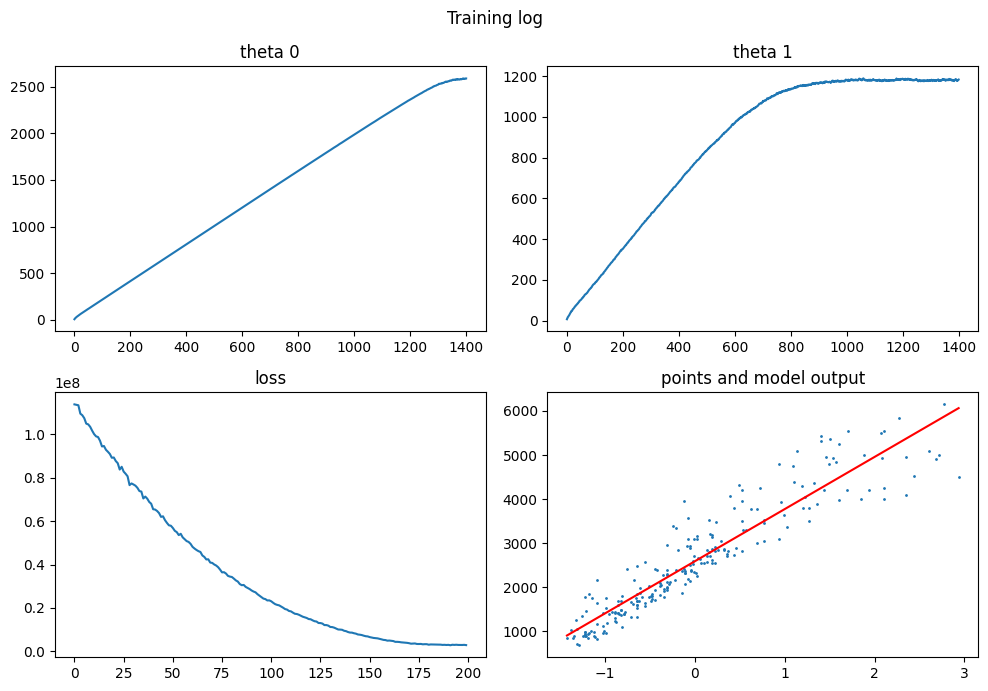

In [23]:
rng = reset_seed()  # to have reproducible results

alpha = 2.0  # global learning rate
beta_rmsprop = 0.9  # memory factor for squared gradients
epsilon = 1e-8  # numerical stability

epochs = 200
batch_size = 32  # B
N = len(living_area_norm)

s0 = 0.0  # s for theta_0
s1 = 0.0  # s for theta_1

t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        for i in range(batch_size):
            n = indices[batch * batch_size + i]

            cg.reset_values()
            cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
            cg.backward()

            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v

        grad_t0 = t0_grad_sum / batch_size
        grad_t1 = t1_grad_sum / batch_size

        s0 = beta_rmsprop * s0 + (1 - beta_rmsprop) * grad_t0**2
        s1 = beta_rmsprop * s1 + (1 - beta_rmsprop) * grad_t1**2

        t0 -= alpha * grad_t0 / (np.sqrt(s0 + epsilon))
        t1 -= alpha * grad_t1 / (np.sqrt(s1 + epsilon))

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("RMSProp with normalized input")
print("theta_0_norm:", t0)
print("theta_1_norm:", t1)

# convert trained normalized parameters back to original scale
t1_rmsprop_original = t1 / x_std
t0_rmsprop_original = t0 - t1 * x_mean / x_std

print("\nConverted back to original scale")
print("intercept theta_0:", t0_rmsprop_original)
print("slope theta_1    :", t1_rmsprop_original)

y_hat_rmsprop = t0 + t1 * living_area_norm
J_rmsprop = mse_loss(y_hat_rmsprop, rent_price)

print("\nThe total value of the loss is", J_rmsprop)

plot_training_log(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    living_area_norm,
    rent_price,
)

**Observations**

- Parameter evolution: RMSProp adapts the effective learning rate of each parameter based on the moving average of squared gradients. The parameters converge close to the reference solution without manually choosing separate learning rates for $\theta_0$ and $\theta_1$.
- Loss evolution: The loss decreases more gradually than in the normalized batched gradient descent experiment. This is not a problem, but a consequence of the chosen RMSProp parameters. The running root mean square of the gradients scales the updates and makes them more conservative. A larger learning rate can make the loss decrease faster, but it also leads to more oscillation or noise around the optimum.
- Final result: After converting the trained parameters back to the original scale, RMSProp reaches $\theta_0$ = 649.45 and $\theta_1$ = 19.69, compared to the reference values $\theta_0$ = 657.69 and $\theta_1$ = 19.66. The final loss is 104930.10, which is only slightly above the minimum reference loss of 104915.13.
- Interpretation: RMSProp performs much better than the unnormalized batched gradient descent and reaches a result close to the optimum. Compared to normalized batched gradient descent, the result is similarly good, but RMSProp achieves this through adaptive parameter-wise gradient scaling instead of manually choosing separate learning rates for $\theta_0$ and $\theta_1$.


#### 6.2.2 Nesterov accelerated gradient

Nesterov accelerated gradient is a modification of classical momentum. The idea is to evaluate the gradient not at the current parameter position, but at a look-ahead position. This means that the current momentum direction is first taken into account before the gradient is computed.

For each parameter, the update rule is:

$$
m^{(t+1)}
=
\beta m^{(t)}
+
\alpha \nabla C\left(\theta^{(t)} - \beta m^{(t)}\right)
$$

$$
\theta^{(t+1)}
=
\theta^{(t)}
-
m^{(t+1)}
$$

Here, $m^{(t)}$ is the accumulated momentum, $\theta^{(t)} - \beta m^{(t)}$ is the look-ahead position, $\alpha$ is the learning rate, and $\beta$ controls how strongly previous update directions are retained. In the implementation below, the gradient is averaged over mini-batches before applying the update.


Nesterov accelerated gradient with normalized input
theta_0_norm: 2596.980668946534
theta_1_norm: 1180.6855065699833

Converted back to original scale
intercept theta_0: 662.4030500745373
slope theta_1    : 19.640813517313376

The total value of the loss is 104919.54650472468


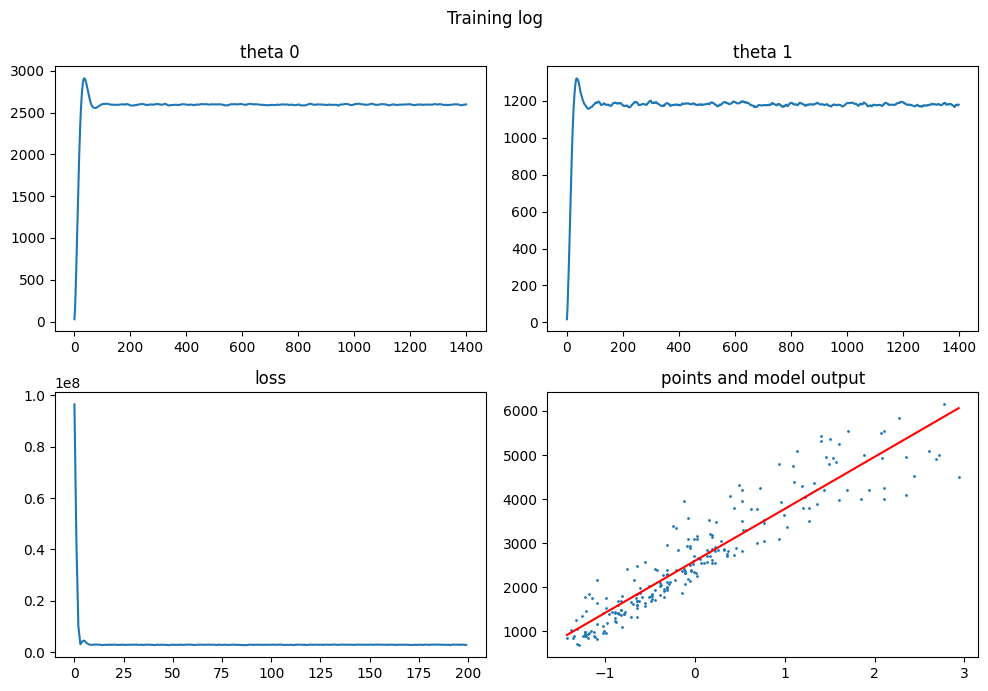

In [23]:
rng = reset_seed()  # to have reproducible results

alpha = 0.01  # learning rate
beta_nesterov = 0.9  # momentum factor

epochs = 200
batch_size = 32
N = len(living_area_norm)

t0 = 0.0  # theta_0 on the normalized input scale
t1 = 0.0  # theta_1 on the normalized input scale

m0 = 0.0  # momentum for theta_0
m1 = 0.0  # momentum for theta_1

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        # look-ahead parameters
        lookahead_t0 = t0 - beta_nesterov * m0
        lookahead_t1 = t1 - beta_nesterov * m1

        for i in range(batch_size):
            n = indices[batch * batch_size + i]

            cg.reset_values()
            cg.forward([living_area_norm[n], lookahead_t0, lookahead_t1, rent_price[n]])
            cg.backward()

            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v

        grad_t0 = t0_grad_sum / batch_size
        grad_t1 = t1_grad_sum / batch_size

        m0 = beta_nesterov * m0 + alpha * grad_t0
        m1 = beta_nesterov * m1 + alpha * grad_t1

        t0 -= m0
        t1 -= m1

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("Nesterov accelerated gradient with normalized input")
print("theta_0_norm:", t0)
print("theta_1_norm:", t1)

# convert trained normalized parameters back to original scale
t1_nesterov_original = t1 / x_std
t0_nesterov_original = t0 - t1 * x_mean / x_std

print("\nConverted back to original scale")
print("intercept theta_0:", t0_nesterov_original)
print("slope theta_1    :", t1_nesterov_original)

y_hat_nesterov = t0 + t1 * living_area_norm
J_nesterov = mse_loss(y_hat_nesterov, rent_price)

print("\nThe total value of the loss is", J_nesterov)

plot_training_log(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    living_area_norm,
    rent_price,
)

**Observations**

- Parameter evolution: Nesterov momentum leads to a very fast initial movement of both parameters. Both $\theta_0$ and $\theta_1$ overshoot the reference values at the beginning, but then quickly move back and stabilize close to the optimum.
- Loss evolution: The loss drops very sharply in the first few epochs and then stays close to the minimum. This shows that Nesterov momentum strongly accelerates convergence, but with the chosen learning rate and momentum factor it also introduces a short initial overshoot.
- Final result: Nesterov reaches $\theta_0$ = 662.40 and $\theta_1$ = 19.64, compared to the reference values $\theta_0$ = 657.69 and $\theta_1$ = 19.66. The final loss is 104919.55, which is close to the minimum reference loss of 104915.13.
- Interpretation: Nesterov momentum performs very well in this normalized setting. It converges much faster than plain normalized batched gradient descent and reaches almost the same optimum, but the aggressive initial acceleration makes the parameter curves less smooth.


#### 6.2.3 Adam

Adam combines the ideas of Momentum and RMSProp. It keeps a moving average of the gradients and a moving average of the squared gradients. The first moving average acts like momentum, while the second one adapts the effective learning rate of each parameter.

The first moment update is

$$
m^{(t+1)} = \beta_1 m^{(t)} + (1 - \beta_1) \nabla C(\theta^{(t)})
$$

The second moment update is

$$
s^{(t+1)} = \beta_2 s^{(t)} + (1 - \beta_2) \nabla C(\theta^{(t)}) \odot \nabla C(\theta^{(t)})
$$

Bias correction is then applied:

$$
\hat{m}^{(t+1)} = \frac{m^{(t+1)}}{1 - \beta_1^{t+1}}
$$

$$
\hat{s}^{(t+1)} = \frac{s^{(t+1)}}{1 - \beta_2^{t+1}}
$$

The parameter update is

$$
\theta^{(t+1)} = \theta^{(t)} - \alpha \frac{\hat{m}^{(t+1)}}{\sqrt{\hat{s}^{(t+1)} + \epsilon}}
$$

Here, $m^{(t)}$ stores the moving average of the gradients, $s^{(t)}$ stores the moving average of squared gradients, $\beta_1$ controls the momentum memory, $\beta_2$ controls the squared-gradient memory, $\alpha$ is the global learning rate, and $\epsilon$ avoids division by zero. The operation $\odot$, the square root and the division are applied element-wise.

In this notebook, the average gradient over each mini-batch is used as $\nabla C(\theta^{(t)})$.


Adam with normalized input
theta_0_norm: 2595.039219199746
theta_1_norm: 1182.1686277603928

Converted back to original scale
intercept theta_0: 658.0314755865927
slope theta_1    : 19.665485376637736

The total value of the loss is 104915.45781694766


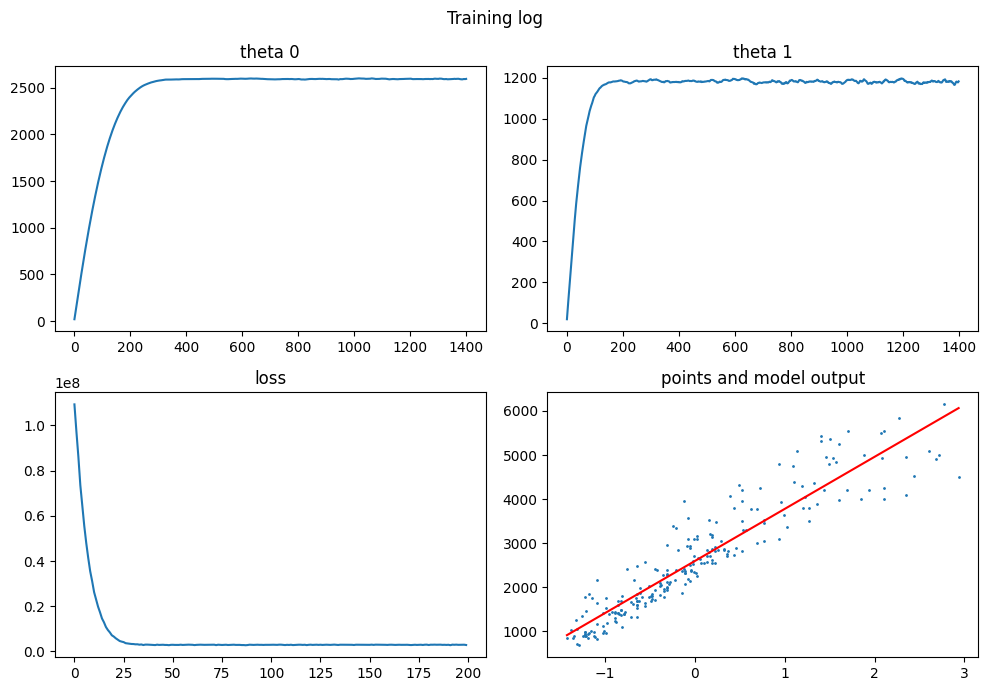

In [24]:
rng = reset_seed()  # to have reproducible results

alpha = 20.0  # global learning rate
beta1 = 0.9  # momentum memory
beta2 = 0.999  # squared-gradient memory
epsilon = 1e-8  # numerical stability

epochs = 200
batch_size = 32
N = len(living_area_norm)

t0 = 0.0  # theta_0 on the normalized input scale
t1 = 0.0  # theta_1 on the normalized input scale

m0 = 0.0  # first moment for theta_0
m1 = 0.0  # first moment for theta_1
v0 = 0.0  # second moment for theta_0
v1 = 0.0  # second moment for theta_1

update_step = 0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for batch in range(N // batch_size):
        update_step += 1

        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        for i in range(batch_size):
            n = indices[batch * batch_size + i]

            cg.reset_values()
            cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
            cg.backward()

            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v

        grad_t0 = t0_grad_sum / batch_size
        grad_t1 = t1_grad_sum / batch_size

        m0 = beta1 * m0 + (1 - beta1) * grad_t0
        m1 = beta1 * m1 + (1 - beta1) * grad_t1

        v0 = beta2 * v0 + (1 - beta2) * grad_t0**2
        v1 = beta2 * v1 + (1 - beta2) * grad_t1**2

        m0_hat = m0 / (1 - beta1**update_step)
        m1_hat = m1 / (1 - beta1**update_step)

        v0_hat = v0 / (1 - beta2**update_step)
        v1_hat = v1 / (1 - beta2**update_step)

        t0 -= alpha * m0_hat / (np.sqrt(v0_hat + epsilon))
        t1 -= alpha * m1_hat / (np.sqrt(v1_hat + epsilon))

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("Adam with normalized input")
print("theta_0_norm:", t0)
print("theta_1_norm:", t1)

# convert trained normalized parameters back to original scale
t1_adam_original = t1 / x_std
t0_adam_original = t0 - t1 * x_mean / x_std

print("\nConverted back to original scale")
print("intercept theta_0:", t0_adam_original)
print("slope theta_1    :", t1_adam_original)

y_hat_adam = t0 + t1 * living_area_norm
J_adam = mse_loss(y_hat_adam, rent_price)

print("\nThe total value of the loss is", J_adam)

plot_training_log(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    living_area_norm,
    rent_price,
)

**Observations**

- Parameter evolution: Adam combines momentum with adaptive gradient scaling. Both parameters converge very quickly on the normalized input scale and then stabilize close to the reference solution.
- Loss evolution: The loss drops steeply in the first epochs and then stays close to the minimum. Compared to RMSProp, Adam converges faster and more directly in this setting, because the momentum term helps to accelerate the movement towards the optimum.
- Final result: Adam reaches $\theta_0$ = 658.03 and $\theta_1$ = 19.67, compared to the reference values $\theta_0$ = 657.69 and $\theta_1$ = 19.66. The final loss is 104915.46, which is almost identical to the minimum reference loss of 104915.13.
- Interpretation: Adam performs very well in this normalized setting. It reaches the optimum almost as accurately as normalized batched gradient descent, but with faster initial convergence. It avoids manually choosing separate learning rates for $\theta_0$ and $\theta_1$ by combining momentum with adaptive parameter-wise scaling.


### 6.3 Learning rate decay on plateau

This experiment uses normalized mini-batch gradient descent. The optimizer itself is the same as in Section 6.1. The difference is that the learning rate is no longer fixed. Instead, it is reduced when the epoch loss does not improve for several epochs.  
This strategy is not a different optimizer like RMSProp, Nesterov, or Adam. It is a learning-rate scheduling strategy that can be combined with many optimizers.


Learning rate decay on plateau with normalized input
final learning rate: 1e-05
theta_0_norm: 2593.955361540897
theta_1_norm: 1182.4979288812078

Converted back to original scale
intercept theta_0: 656.4080512314019
slope theta_1    : 19.670963331494455

The total value of the loss is 104915.35387054487


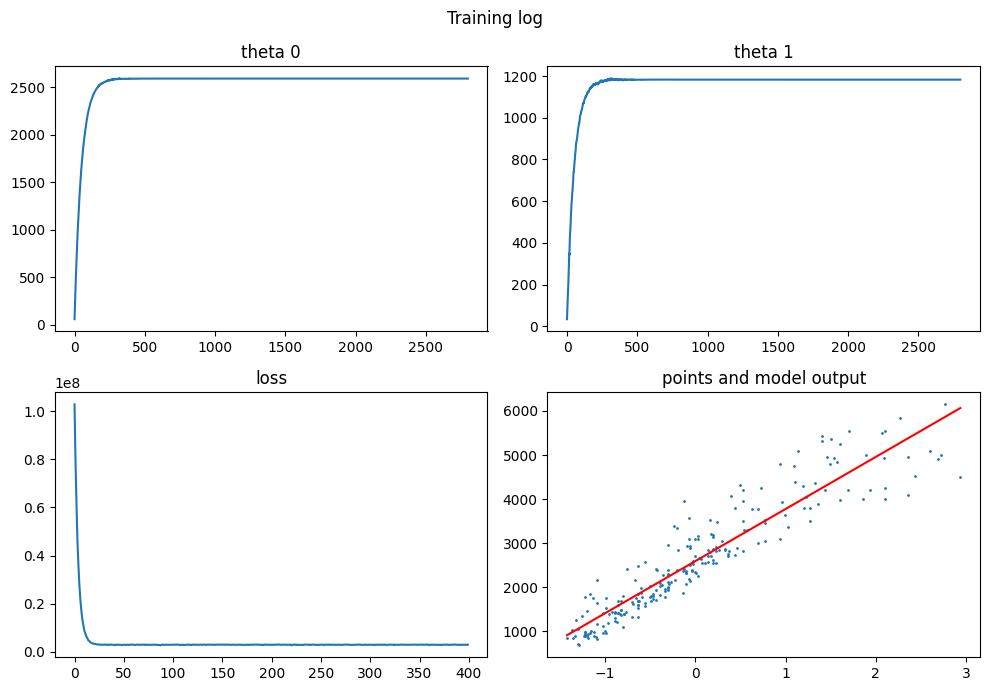

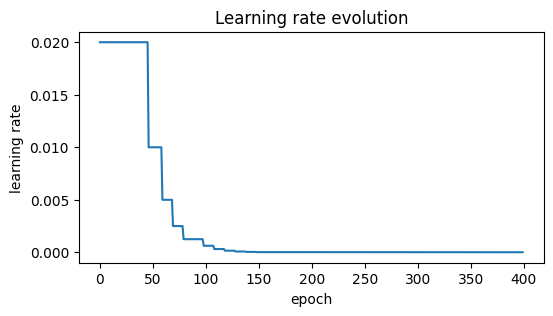

In [25]:
rng = reset_seed()  # to have reproducible results

alpha = 0.02
lr_decay_factor = 0.5
lr_patience = 10
min_alpha = 1e-5
min_delta = 1e-2

epochs = 400
batch_size = 32
N = len(living_area_norm)

t0 = 0.0  # theta_0 on the normalized input scale
t1 = 0.0  # theta_1 on the normalized input scale

best_loss = np.inf
epochs_without_improvement = 0

loss_evolution = []
alpha_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    indices = rng.permutation(N)
    n_steps = N // batch_size + 1
    epoch_loss = 0.0

    for batch in range(N // batch_size):
        t0_grad_sum = 0.0
        t1_grad_sum = 0.0

        for i in range(batch_size):
            n = indices[batch * batch_size + i]

            cg.reset_values()
            cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
            cg.backward()

            t0_grad_sum += theta_0.grad_v
            t1_grad_sum += theta_1.grad_v
            epoch_loss += j.v

        t0 -= alpha * t0_grad_sum / batch_size
        t1 -= alpha * t1_grad_sum / batch_size

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    epoch_loss_average = epoch_loss / n_steps
    loss_evolution.append(epoch_loss_average)
    alpha_evolution.append(alpha)

    if epoch_loss_average < best_loss - min_delta:
        best_loss = epoch_loss_average
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= lr_patience:
        alpha = max(alpha * lr_decay_factor, min_alpha)
        epochs_without_improvement = 0

print("Learning rate decay on plateau with normalized input")
print("final learning rate:", alpha)
print("theta_0_norm:", t0)
print("theta_1_norm:", t1)

t1_decay_original = t1 / x_std
t0_decay_original = t0 - t1 * x_mean / x_std

print("\nConverted back to original scale")
print("intercept theta_0:", t0_decay_original)
print("slope theta_1    :", t1_decay_original)

y_hat_decay = t0 + t1 * living_area_norm
J_decay = mse_loss(y_hat_decay, rent_price)

print("\nThe total value of the loss is", J_decay)

plot_training_log(
    loss_evolution,
    t0_evolution,
    t1_evolution,
    living_area_norm,
    rent_price,
)

plt.figure(figsize=(6, 3))
plt.plot(alpha_evolution)
plt.title("Learning rate evolution")
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.show()

**Observations**

- Parameter evolution: Compared to the fixed learning-rate experiment in Section 6.1, the parameters move faster at the beginning because the initial learning rate is larger. After the learning rate is reduced, both parameters stabilize close to the normalized reference values.
- Loss evolution: The loss drops very quickly at the beginning and then reaches a plateau close to the minimum. Once the improvement becomes too small for several epochs, the learning rate is reduced step by step from 0.02 down to 1e-5. This makes the later updates smaller and avoids unnecessary oscillations near the optimum.
- Final result: The model reaches $\theta_0$ = 656.41 and $\theta_1$ = 19.67, compared to the normal-equation reference values $\theta_0$ = 657.69 and $\theta_1$ = 19.66. The final loss is 104915.35, which is almost identical to the reference loss of 104915.13 and slightly lower than the fixed learning-rate result from Section 6.1.
- Interpretation: Learning rate decay on plateau is useful when a larger learning rate helps at the beginning, but smaller updates are needed near the optimum. In this simple normalized linear regression problem, the improvement over Section 6.1 is small because the fixed learning rate already works very well. However, the scheduler gives a more robust training strategy because it automatically reduces the learning rate once progress slows down.


### 6.4 Model complexity and additional features

The previous experiments focused mainly on optimization. In this section, the model class itself is changed. First, a second-order model is tested using only the living area. Then, the number of rooms is added as a second feature. This allows us to compare whether the training loss improves more by adding nonlinear terms, by adding another input feature, or by combining both.


#### 6.4.1 Second-order model with living area only

The previous models assumed a linear relationship between living area and rent price. A second-order model adds a quadratic term and can represent curved relationships:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2
$$

The model is fitted with the normal equation on the normalized input. This gives a direct reference solution for the second-order model.


Second-order model on normalized input
theta_0_norm: 2720.140836964749
theta_1_norm: 1295.4701155616635
theta_2_norm: -125.86810969202102

Linear reference loss: 104915.13056913584
Second-order reference loss: 94056.03163909209

Converted back to original scale
theta_0: 259.56185275163625
theta_1: 28.41182630920305
theta_2: -0.03483101979527974


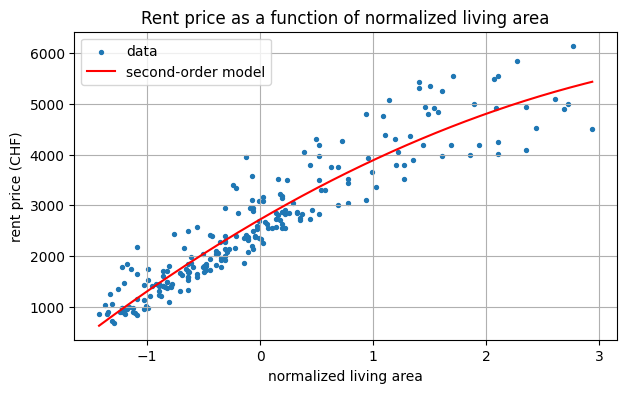

In [26]:
# second-order model on normalized input
X_poly_norm = np.c_[
    np.ones(len(living_area_norm)),
    living_area_norm,
    living_area_norm**2,
]

theta_poly_norm = inv(X_poly_norm.T @ X_poly_norm) @ X_poly_norm.T @ rent_price

print("Second-order model on normalized input")
print("theta_0_norm:", theta_poly_norm[0])
print("theta_1_norm:", theta_poly_norm[1])
print("theta_2_norm:", theta_poly_norm[2])

y_hat_poly_norm = theta_poly_norm[0] + theta_poly_norm[1] * living_area_norm + theta_poly_norm[2] * living_area_norm**2

J_poly_norm = mse_loss(y_hat_poly_norm, rent_price)

print("\nLinear reference loss:", J_norm_ref)
print("Second-order reference loss:", J_poly_norm)

# convert normalized second-order parameters back to original input scale
theta_2_poly_original = theta_poly_norm[2] / x_std**2
theta_1_poly_original = theta_poly_norm[1] / x_std - 2 * theta_poly_norm[2] * x_mean / x_std**2
theta_0_poly_original = theta_poly_norm[0] - theta_poly_norm[1] * x_mean / x_std + theta_poly_norm[2] * x_mean**2 / x_std**2

print("\nConverted back to original scale")
print("theta_0:", theta_0_poly_original)
print("theta_1:", theta_1_poly_original)
print("theta_2:", theta_2_poly_original)

x_curve_norm = np.linspace(np.min(living_area_norm), np.max(living_area_norm), 200)
y_curve_poly_norm = theta_poly_norm[0] + theta_poly_norm[1] * x_curve_norm + theta_poly_norm[2] * x_curve_norm**2

plt.figure(figsize=(7, 4))
plt.scatter(living_area_norm, rent_price, s=8, label="data")
plt.plot(x_curve_norm, y_curve_poly_norm, color="red", label="second-order model")
plt.title("Rent price as a function of normalized living area")
plt.xlabel("normalized living area")
plt.ylabel("rent price (CHF)")
plt.legend()
plt.grid(True)
plt.show()

**Observations**

- Model behaviour: The second-order model introduces a small downward curvature. This is visible in the plot, where the fitted curve still follows the main linear trend but bends slightly for larger living areas.
- Loss comparison: The second-order model reduces the loss from 104915.13 for the linear reference model to 94056.03. This means that the quadratic term improves the fit on the training data.
- Parameters: The quadratic coefficient is negative, with $\theta_2$ = -0.0348 on the original scale. This indicates that the predicted rent price still increases with living area, but the increase becomes slightly smaller for larger apartments.
- Interpretation: The second-order model fits the dataset better than the simple linear model, but the improvement should be interpreted carefully because it is evaluated on the same data used for fitting. A train-test split would be needed to check whether the quadratic model generalizes better or only fits the training data more closely.


#### 6.4.2 Adding number of rooms as a second feature

The previous models only used the living area as input. However, the dataset also contains the number of rooms, which is another relevant feature for predicting rent price. Therefore, two additional models are fitted with the normal equation.

The first model is a linear model with two input features:

$$
\hat{y} = \theta_0 + \theta_1 x_{\text{area}} + \theta_2 x_{\text{rooms}}
$$

The second model also includes quadratic terms and an interaction term:

$$
\hat{y}
= \theta_0
+ \theta_1 x_{\text{area}}
+ \theta_2 x_{\text{rooms}}
+ \theta_3 x_{\text{area}}^2
+ \theta_4 x_{\text{rooms}}^2
+ \theta_5 x_{\text{area}} x_{\text{rooms}}
$$

Both features are normalized before fitting. The goal is not to study optimizer convergence again, but to check whether adding more input information improves the achievable training loss.


In [27]:
# get the data for number of rooms
number_of_rooms = dataset["nb_rooms"].values

In [28]:
# normalize number of rooms
rooms_mean = np.mean(number_of_rooms)
rooms_std = np.std(number_of_rooms)

number_of_rooms_norm = (number_of_rooms - rooms_mean) / rooms_std

print("Mean of original number of rooms:", rooms_mean)
print("Std of original number of rooms :", rooms_std)
print("Mean after normalization        :", np.mean(number_of_rooms_norm))
print("Std after normalization         :", np.std(number_of_rooms_norm))

Mean of original number of rooms: 3.484848484848485
Std of original number of rooms : 1.6956743664777558
Mean after normalization        : -6.151885158096106e-17
Std after normalization         : 1.0


In [29]:
# linear model with two features: living area and number of rooms
X_two_features = np.c_[
    np.ones(len(living_area_norm)),
    living_area_norm,
    number_of_rooms_norm,
]

theta_two_features = inv(X_two_features.T @ X_two_features) @ X_two_features.T @ rent_price

y_hat_two_features = theta_two_features[0] + theta_two_features[1] * living_area_norm + theta_two_features[2] * number_of_rooms_norm

J_two_features = mse_loss(y_hat_two_features, rent_price)

print("Linear model with living area and number of rooms")
print("theta_0:", theta_two_features[0])
print("theta_1 area :", theta_two_features[1])
print("theta_2 rooms:", theta_two_features[2])

print("\nLinear reference loss with living area only:", J_norm_ref)
print("Linear two-feature loss:", J_two_features)

Linear model with living area and number of rooms
theta_0: 2594.2727272727275
theta_1 area : 1201.0765777560975
theta_2 rooms: -20.913259076159278

Linear reference loss with living area only: 104915.13056913584
Linear two-feature loss: 104880.13082692951


In [30]:
# second-order model with living area, number of rooms and interaction term
X_poly_two_features = np.c_[
    np.ones(len(living_area_norm)),
    living_area_norm,
    number_of_rooms_norm,
    living_area_norm**2,
    number_of_rooms_norm**2,
    living_area_norm * number_of_rooms_norm,
]

theta_poly_two_features = inv(X_poly_two_features.T @ X_poly_two_features) @ X_poly_two_features.T @ rent_price

y_hat_poly_two_features = (
    theta_poly_two_features[0]
    + theta_poly_two_features[1] * living_area_norm
    + theta_poly_two_features[2] * number_of_rooms_norm
    + theta_poly_two_features[3] * living_area_norm**2
    + theta_poly_two_features[4] * number_of_rooms_norm**2
    + theta_poly_two_features[5] * living_area_norm * number_of_rooms_norm
)

J_poly_two_features = mse_loss(y_hat_poly_two_features, rent_price)

print("Second-order model with living area and number of rooms")
print("theta_0:", theta_poly_two_features[0])
print("theta_1 area       :", theta_poly_two_features[1])
print("theta_2 rooms      :", theta_poly_two_features[2])
print("theta_3 area^2     :", theta_poly_two_features[3])
print("theta_4 rooms^2    :", theta_poly_two_features[4])
print("theta_5 area*rooms :", theta_poly_two_features[5])

print("\nLinear reference loss with living area only:", J_norm_ref)
print("Second-order area-only loss:", J_poly_norm)
print("Linear two-feature loss:", J_two_features)
print("Second-order two-feature loss:", J_poly_two_features)

Second-order model with living area and number of rooms
theta_0: 2775.8969940045463
theta_1 area       : 1531.873576239478
theta_2 rooms      : -235.76587714801278
theta_3 area^2     : -118.33825390193121
theta_4 rooms^2    : -54.35762772538342
theta_5 area*rooms : -9.741947616245682

Linear reference loss with living area only: 104915.13056913584
Second-order area-only loss: 94056.03163909209
Linear two-feature loss: 104880.13082692951
Second-order two-feature loss: 88862.18779467346


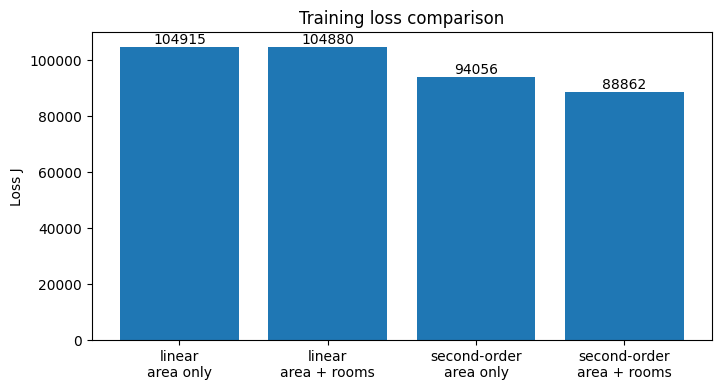

Second-order two-feature model evaluation
Loss J     : 88862.19
RMSE (CHF) : 421.57
MAE (CHF)  : 327.84
MAPE (%)   : 13.71%


In [31]:
loss_labels = [
    "linear\narea only",
    "linear\narea + rooms",
    "second-order\narea only",
    "second-order\narea + rooms",
]

loss_values = [
    J_norm_ref,
    J_two_features,
    J_poly_norm,
    J_poly_two_features,
]

plt.figure(figsize=(8, 4))
bars = plt.bar(loss_labels, loss_values)

for bar, value in zip(bars, loss_values, strict=False):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.0f}",
        ha="center",
        va="bottom",
    )

plt.title("Training loss comparison")
plt.ylabel("Loss J")
plt.show()

rmse_poly_two_features = rmse_loss(y_hat_poly_two_features, rent_price)
mae_poly_two_features = mae_loss(y_hat_poly_two_features, rent_price)
mape_poly_two_features = 100 * mape_loss(y_hat_poly_two_features, rent_price)

print("Second-order two-feature model evaluation")
print("Loss J     :", round(J_poly_two_features, 2))
print("RMSE (CHF) :", round(rmse_poly_two_features, 2))
print("MAE (CHF)  :", round(mae_poly_two_features, 2))
print("MAPE (%)   :", f"{mape_poly_two_features:.2f}%")

**Observations**

- Adding the number of rooms to the linear model only gives a very small improvement. The loss decreases from 104915.13 to 104880.13, which means that most of the useful information is already captured by the living area.
- The coefficient of the number of rooms is negative in the linear two-feature model. This does not mean that more rooms generally reduce the rent price. It means that, after controlling for living area, apartments with more rooms tend to have smaller rooms, which can slightly reduce the predicted rent.
- The second-order area-only model already improves the loss clearly, from 104915.13 to 94056.03. This shows that the relationship between living area and rent price is not perfectly linear.
- The second-order two-feature model gives the lowest training loss, with $J = 88862.19$. Compared to the original linear area-only model, the RMSE is reduced from 458 CHF to 422 CHF, the MAE from 347 CHF to 328 CHF, and the MAPE from 14.6% to 13.7%.
- In this case, the additional room information and the interaction term provide a clearer improvement than in the purely linear model. However, since all models are evaluated on the training data, the lower loss should be interpreted carefully. A train-test split would be needed to check whether the more complex model also generalizes better.


## 7. Final conclusion

This notebook demonstrates the full workflow from a simple computational graph to gradient-based optimization and model comparison. The normal equation first provides a reference solution for linear regression. Plain stochastic and mini-batch gradient descent can approximate this solution, but their convergence strongly depends on feature scaling and on the chosen learning rate.

The first important observation is that the original input scale makes optimization difficult. The living area values are much larger than the constant bias input, which leads to very different gradient magnitudes for $\theta_0$ and $\theta_1$. As a result, the slope parameter converges quickly, while the intercept changes only very slowly. Using different learning rates and momentum can improve this behaviour, but the most important practical improvement is zero-mean normalization.

After normalization, mini-batch gradient descent reaches a solution very close to the normal-equation reference. This shows that normalization does not change the theoretical optimum of the linear model, but strongly improves the numerical behaviour of gradient-based optimization. Advanced optimizers such as RMSProp, Nesterov momentum and Adam also perform well on the normalized input. Adam and Nesterov converge especially quickly, while RMSProp and Adam reduce the need for manually choosing separate learning rates for individual parameters. However, the global learning rate remains an important hyperparameter for all optimizers and was selected empirically in these experiments. Learning-rate decay on plateau makes the training process more robust by reducing the step size near the optimum.

The final experiments change the model class itself. Adding only the number of rooms to the linear model gives almost no improvement, because most of the useful information is already captured by the living area. In contrast, adding a quadratic term for the living area clearly reduces the training loss, which indicates that the relationship between living area and rent price is not perfectly linear. The lowest training loss is obtained by the second-order model with both living area and number of rooms, including quadratic and interaction terms. However, this final comparison is based only on the training data. Therefore, the lower loss should be interpreted as a better training fit, not as proof of better generalization. A train-test split or cross-validation would be needed to check whether the more complex models also perform better on unseen data.
